## 04. Pytorch Custom Datasets

In [1]:
import torch
from torch import nn

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
!nvidia-smi

Mon Aug 10 22:57:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P0             15W /  112W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#### 1. Get Dataset
Datasets is a subset of Food101 dataset.
Datasets starts 3 classes of food and only 10% of the images(~75 training, 25 testing)

In [4]:
%pip install requests
import requests
import zipfile
from pathlib import Path

# Setup the to a data folder
data_path = Path("data_custom/")
image_path = data_path / "pizza_steak_sushi"

# Download the satasets
if image_path.is_file():
    print(f'{image_path} directory already exists ')
else: 
    print(f'{image_path} directory does not exits, creating one...')
    image_path.mkdir(parents=True, exist_ok=True)

with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print('Downloading pizza steak and sushi')
    f.write(request.content)

# Unzip data
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print('Unzipping data')
    zip_ref.extractall(image_path)




[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
data_custom\pizza_steak_sushi directory does not exits, creating one...
Unzipping data


#### 2.Data preparation and data exploration

In [5]:
import os
def walk_through_dir(dir_path):
    """Walks through the dir)path returning its  content."""
    for dirpath, dirnames,filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data_custom\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data_custom\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data_custom\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data_custom\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data_custom\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data_custom\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data_custom\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data_custom\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data_custom\pizza_steak_sushi\train\sushi'.


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data_custom/pizza_steak_sushi/train'),
 WindowsPath('data_custom/pizza_steak_sushi/test'))

##### 2.1 Visualizing the image
1. Get all of the images paths
2. pick a random image using python's random.choice()
3. Get the image class naem using `pathlib.Path.parent.stem`
4. Open the image with python's PIL
5. Show the image and metadata

In [8]:
image_path

WindowsPath('data_custom/pizza_steak_sushi')

Random image path: data_custom\pizza_steak_sushi\test\sushi\2394442.jpg
Image class: sushi
Image height: 408
Image width: 512


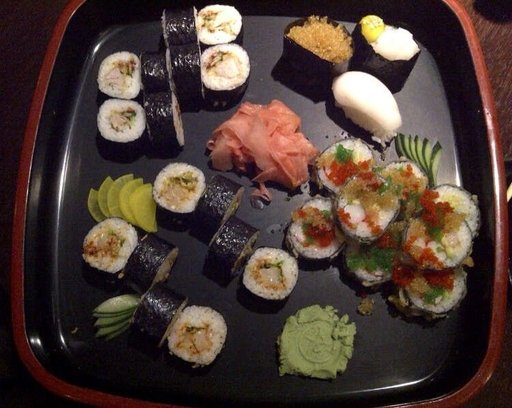

In [9]:
import random
from PIL import Image

# Set seed
random.seed(42)

#  1. Get all images paths
images_path_list = list(image_path.glob("*/*/*.jpg"))
images_path_list

# 2. Pick a random image
random_image_path = random.choice(images_path_list)
random_image_path

# 3. Get image class from path name (the image is in the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
#print(image_class)

# 4. Open image
img = Image.open(random_image_path)

# 5.print meatadata
print(f'Random image path: {random_image_path}')
print(f'Image class: {image_class}')
print(f'Image height: {img.height}')
print(f'Image width: {img.width}')
img

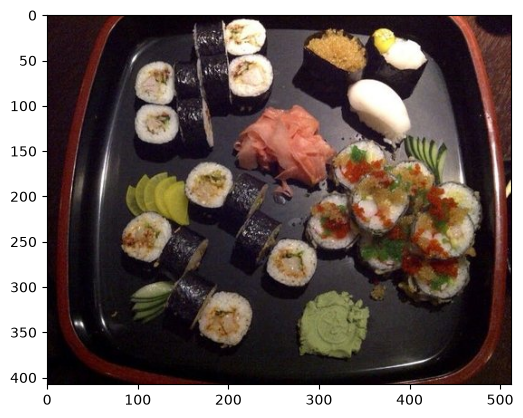

In [10]:
import matplotlib.pyplot as plt
plt.imshow(img)



In [11]:
import numpy as np
img_as_array = np.asarray(img)
img_as_array.shape

(408, 512, 3)

#### 3. Transforming data
1. Turn your target data into tensor
2. Turn it into a `torch.util.data.dataloader` and subsequently a `torch.util.data.DataLoader`

In [12]:
import torch 
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

##### 3.1 Transorming data into `torchvision.transforms`

In [13]:
data_transform = transforms.Compose([
    # Resize our images to 64 x 64
    transforms.Resize(size=(64, 64)),
    # Flip the images random on the horizontally 
    transforms.RandomHorizontalFlip(p=0.5),
    # Turn the image into a torch.tensor
    transforms.ToTensor()
])

In [14]:
data_transform(img)

tensor([[[0.1294, 0.1373, 0.1412,  ..., 0.0863, 0.0824, 0.0824],
         [0.1255, 0.1373, 0.1412,  ..., 0.0902, 0.0902, 0.0902],
         [0.1294, 0.1412, 0.1333,  ..., 0.1059, 0.0980, 0.1137],
         ...,
         [0.0157, 0.0196, 0.0157,  ..., 0.1294, 0.1373, 0.1412],
         [0.0275, 0.0275, 0.0275,  ..., 0.1255, 0.1373, 0.1333],
         [0.0314, 0.0314, 0.0275,  ..., 0.1137, 0.1294, 0.1255]],

        [[0.0588, 0.0588, 0.0667,  ..., 0.0392, 0.0431, 0.0431],
         [0.0588, 0.0549, 0.0667,  ..., 0.0392, 0.0431, 0.0353],
         [0.0510, 0.0627, 0.0627,  ..., 0.0471, 0.0471, 0.0392],
         ...,
         [0.0039, 0.0078, 0.0078,  ..., 0.0667, 0.0667, 0.0667],
         [0.0118, 0.0118, 0.0118,  ..., 0.0706, 0.0706, 0.0667],
         [0.0118, 0.0157, 0.0196,  ..., 0.0667, 0.0667, 0.0667]],

        [[0.0667, 0.0667, 0.0667,  ..., 0.0706, 0.0706, 0.0745],
         [0.0784, 0.0784, 0.0863,  ..., 0.0941, 0.0902, 0.0863],
         [0.0824, 0.0863, 0.0941,  ..., 0.0941, 0.1059, 0.

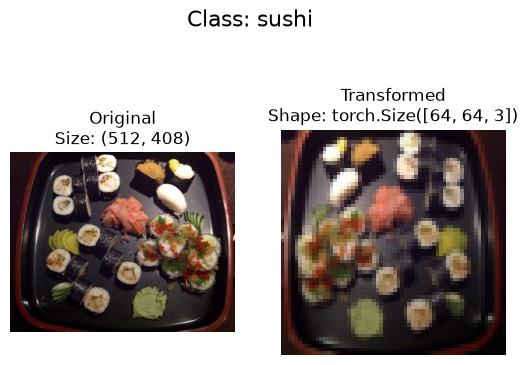

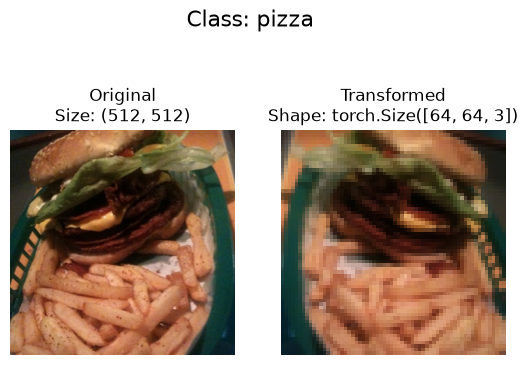

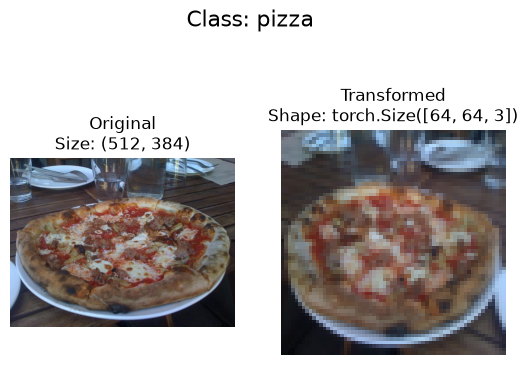

In [15]:
def plot_transformed_image(image_paths:list, transforms, n=3, seed=None):
    if seed:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=3)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f'Original\nSize: {f.size}')
            ax[0].axis(False)

            # Transform and plot target image 
            transformed_image = transforms(f).permute(1,2,0) # Matplotlib need the color channel after the end
            ax[1].imshow(transformed_image)
            ax[1].set_title(f'Transformed\nShape: {transformed_image.shape}')
            ax[1].axis("off")

            fig.suptitle(f'Class: {image_path.parent.stem}', fontsize=16)

plot_transformed_image(image_paths=images_path_list, transforms=data_transform, n=3, seed=42)

#### 4. option 1 Loading image data using `Image Folder`

In [16]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data_custom\pizza_steak_sushi\train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data_custom\pizza_steak_sushi\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [17]:
train_dir, test_dir

(WindowsPath('data_custom/pizza_steak_sushi/train'),
 WindowsPath('data_custom/pizza_steak_sushi/test'))

In [18]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [19]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [20]:
# Check the length of the datasets
len(train_data), len(test_data)

(225, 75)

In [21]:
# Index on train_data datasets to get a single image and label
train_data[0]

(tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
          [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
          [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
          ...,
          [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
          [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
          [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],
 
         [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
          [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
          [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
          ...,
          [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
          [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
          [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],
 
         [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
          [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
          [0.0902, 0.0902, 0.0902,  ...,

##### 4.1 Turn the images into DataLoader

In [22]:
# Turn train and test data into data loader
from torch.utils.data import DataLoader
BATCH_SIZE = 16
train_dataloader = DataLoader(dataset=train_data,
                            batch_size=BATCH_SIZE,
                            shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)
len(train_dataloader), len(test_dataloader)

(15, 5)

In [23]:
img, label = next(iter(train_dataloader))
print(f'Image shape: {img.shape}')
print(f'Label Shape: {label.shape}')

Image shape: torch.Size([16, 3, 64, 64])
Label Shape: torch.Size([16])


#### 5 Option 2: Loading Image Data with a custom `Dataset`

In [24]:
import os 
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [25]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

##### 5.1  Creating a helper fuction to get class names
We want function to:
1. Get a class names using 'os.scandir' to traverse a target directory(ideally the directory is a standard image classification format) 
2. Raise an error if the class aren't found (if this happens, there might be a something wrong with the directory structure.)
3. Trun the class nmaes into a dict and a list and return them.

In [26]:
# Setup path for target directory
target_directory = train_dir
print(f'Target dir: {target_directory}')

# Get the class names from the target directory
class_names_found = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found

Target dir: data_custom\pizza_steak_sushi\train


['pizza', 'steak', 'sushi']

In [27]:
def find_Classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    # 1. Get the class names by scanning th target directory
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    # 2. Raise an error if the class name could not be found
    if not classes:
        raise FileNotFoundError(f"Couldn't find any classes in {directory}")

    # Create a directory of index label
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}
    return classes, class_to_idx

In [28]:
find_Classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

##### 5.2 Create a custom `Dataset` to replicate `ImageFolder`
To create custom dataset, we wan to:
1. Subclass `torch.utils.Dataset`
2. Init subclass with a target directory (the directory we'd like to get data from) as well as a transform if we'll like to transform our data.
3. Create several attributes:
    * Paths - path of our images
    * transform - the transform we'd like to use
    * classes - list of target classes
    * class_to_idx - a dict of the target classes mapped to integer labels 
4. Create a function to `load_images()`, this function will open an image
5. Overwrite the `__len()__` method to return the length of out dataset
6. Overwrite the `__getitem()__` method to return a given sample when passes an index 

In [29]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
    # 2. Initialize custom data
    def __init__(self,
                 targ_dir: str, 
                 transform: None):
        # 3. Create class attributes 
        # Get all of the image Paths
        self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))
        # Setup transform
        self.transform = transform
        # Create classes and class_to_idx attributes
        self.classes, self.class_to_idx = find_Classes(targ_dir)

    # 4. Create a function to load images 
    def load_image(self, index: int) -> Image.Image:
        "Opens an image via a patha and return it."
        image_path = self.paths[index]
        return Image.open(image_path)
    
    # 5. Overwrite __len__()
    def __len__(self) -> int:
        "Return the total number of samples."
        return len(self.paths)

    # 6. Overwrite __getitem__() method to return a perticular sample
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Return one sample of the data, data and lable(X,y)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name # expects path in format: data_folder/class_name/imeg.jpg
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary 
        if self.transform:
            return self.transform(img), class_idx # return data, label (X, y)
        else: 
            return img, class_idx # return untransformed image and label

In [30]:
# Create a transform
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=[64,64]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=[64,64]),
    transforms.ToTensor()
])

In [31]:
# Test out ImageFolderCustom
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                     transform=test_transforms)

In [32]:
train_data_custom.paths, test_data_custom.class_to_idx

([WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1008844.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1033251.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1044789.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1089334.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1105700.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/12301.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1285298.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/138855.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1412034.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1524655.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1572608.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1633289.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1649276.jpg'),
  WindowsPath('data_custom/pizza_steak_sushi/train/pizza/1654444.jp

##### 5.3 Create a function to display random images


In [33]:
# 1 .Create a funciton to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    # 2. Adjust the display if n is too high
    if n > 10:
        n = 10
        display_shape = False
        print(f'For display, puposes, n shouldnt be lagerger than 10, setting n to 10  and removing shape display.')

    # 3. set the seed
    if seed:
        random.seed(seed) 

    # 4. Get the random sample indexes
    random_samples_idx = random.sample(range(len(dataset)), k=n)

    # 5. Setup plot 
    plt.figure(figsize=(16, 8))

    # 6. Loop through random indexes and plot with matplotlib
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust tesnor dimension for plotting
        targ_image_adjust = targ_image.permute(1, 2, 0)
        # Plot adjusted
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis('off')
        if classes: 
            title = f'Class: {classes[targ_label]}'
            if display_shape:
                title = title + f'\nshape: {targ_image_adjust.shape}'
        plt.title(title)

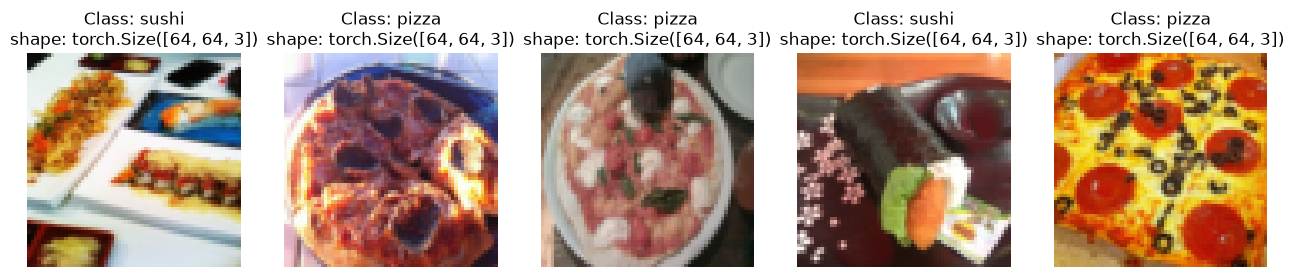

In [34]:
# Diplay random images from the ImageFolder created dataset
display_random_images(train_data,
                      n=5,
                      classes=class_names,
                      seed=42)

For display, puposes, n shouldnt be lagerger than 10, setting n to 10  and removing shape display.


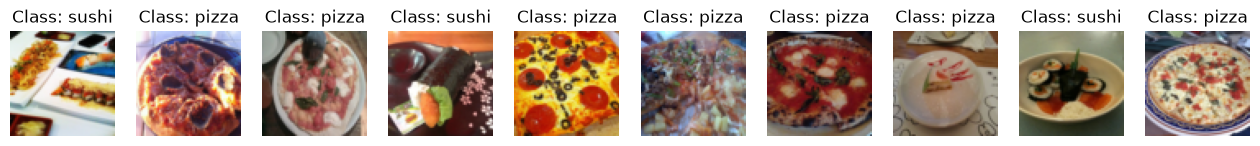

In [35]:
# Display random images from the ImageFoolderCustom Dataset
display_random_images(train_data_custom,
                      n=20,
                      classes=class_names,
                      seed=42)

##### 5.4 Turn Custom loaded images into `DataLoader's`

In [36]:
from torch.utils.data import DataLoader
train_custom_dataloader = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True)

test_custom_dataloader = DataLoader(dataset=test_data_custom,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)

train_custom_dataloader, test_custom_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x260f658fa40>,
 <torch.utils.data.dataloader.DataLoader at 0x260f654be30>)

In [37]:
img_custom, label_custom = next(iter(train_custom_dataloader))
img_custom.shape, label_custom.shape

(torch.Size([16, 3, 64, 64]), torch.Size([16]))

#### 6. Other forms of tranforms(Data Augmentation)

In [38]:
# trivialaugment
from torchvision import transforms

train_tranform = transforms.Compose([transforms.Resize(size=(224, 224)),
                                     transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                     transforms.ToTensor()])

test_transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor()])


In [39]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[WindowsPath('data_custom/pizza_steak_sushi/test/pizza/1152100.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/1503858.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/1687143.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/1925494.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/194643.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/195160.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/2003290.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/2019408.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/2111981.jpg'),
 WindowsPath('data_custom/pizza_steak_sushi/test/pizza/2124579.jpg')]

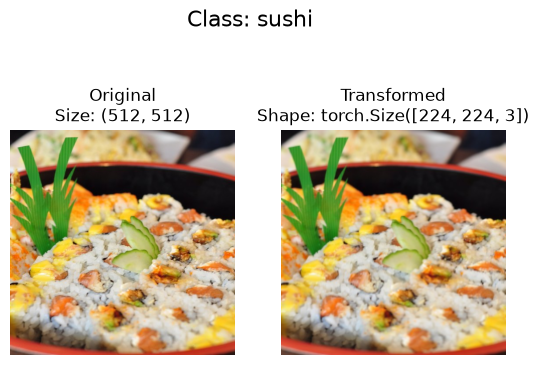

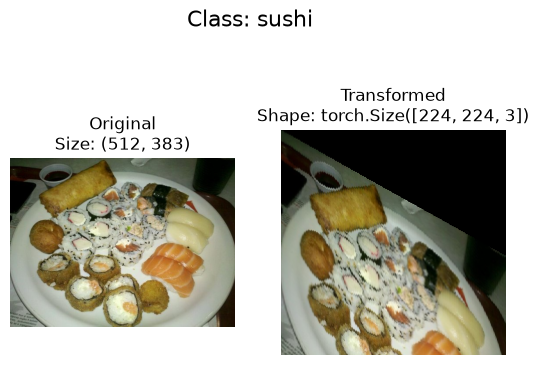

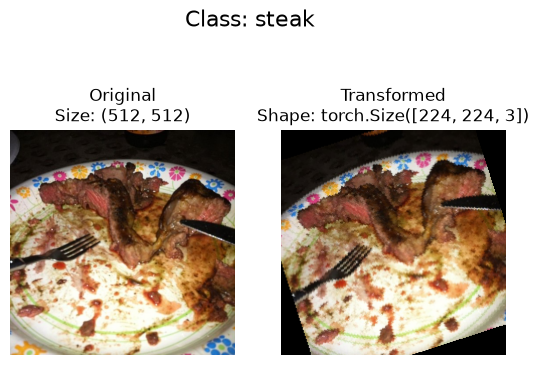

In [40]:
plot_transformed_image(
    image_paths=image_path_list,
    transforms=train_tranform,
    n=3,
    seed=None
)

#### 7. Model00: TinyVGG without augmentation

##### 7.1 Creating transforms and loading data for model 0

In [41]:
# Create Sample transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [42]:
# 1. Load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform)

# 2. Turn dataset into dataloader
import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True)
test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE)

##### 7.2 Create TinyVGG model class

In [43]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape:int,
                hidden_units: int,
                output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                       out_channels=hidden_units,
                       kernel_size=3,
                       stride=1,
                       padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                     out_channels=hidden_units,
                     stride=1,
                     kernel_size=3,
                     padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
                    nn.Conv2d(in_channels=hidden_units,
                               out_channels=hidden_units,
                               kernel_size=3,
                               stride=1,
                               padding=0),
                    nn.ReLU(),
                    nn.Conv2d(in_channels=hidden_units,
                             out_channels=hidden_units,
                             stride=1,
                             kernel_size=3,
                             padding=0),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2,
                                 stride=2) # default stride value is same as ker_size
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 13 * 13,
                      out_features=output_shape)
        )
    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # benefits from operator fusion

In [44]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels
                  hidden_units=10,
                  output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

##### 7.3 Try a forward pass on a single image (to test the model)

In [45]:
# get a single image batcch
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [46]:
# forwrad pass
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4668e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1816e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3995e-03,  9.4989e-03],
        [ 2.2101e-02, -4.1470e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2410e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

##### 7.4 Use `torchinfo` to get an indea of the shapes going through the model

In [47]:
%pip install torchinfo
import torchinfo
from torchinfo import summary

summary(model_0, input=[1, 3, 64, 64])

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Layer (type:depth-idx)                   Param #
TinyVGG                                  --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       280
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       910
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-6                       910
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       910
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
├─Sequential: 1-3                        --
│    └─Flatten: 2-11                     --
│    └─Linear: 2-12                      5,073
Total params: 8,083
Trainable params: 8,083
Non-trainable params: 0

##### 7.5 Create train and test loops functions

In [48]:
# Create train_step()
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
    # Put the model in train mode
    model.train()

    # Setup train loss and accuracy values
    train_loss, train_acc = 0, 0

    # loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # send the data to target device
        X, y = X.to(device), y.to(device)

        # 1. forward pass
        y_pred = model(X)

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimzer zero grade
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # Optimizer step
        optimizer.step()

        # Calculate accuracy metrics
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/ len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [49]:
# Create a test step
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device=device):
    # Put the model into eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference mode
    with torch.inference_mode():
        # Loss through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate the loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate the accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

##### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [50]:
from tqdm.auto import tqdm

# 1. Create a train function that takes in varios model parameters + optimizer + dataloaders, loss funciton
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int = 5,
          device = device):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}

    # 3. Loop through training and test steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)
        # 4. Print out whats happening
        print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train Acuuracy: {train_acc:.2f} | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}")

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        # 6. Return the filled results at the end of epochs
    return results

c:\Users\danish\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### 7.7 Train and Evaluate model 0

In [51]:
NUM_EPOCHS = 10
model_0 = TinyVGG(input_shape=3,
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        epochs=NUM_EPOCHS,
                        device=device)

 10%|█         | 1/10 [00:00<00:06,  1.49it/s]

Epoch: 0 | Train loss: 1.1015 | Train Acuuracy: 0.28 | Test Loss: 1.0858 | Test Accuracy: 0.30


 20%|██        | 2/10 [00:01<00:04,  1.62it/s]

Epoch: 1 | Train loss: 1.0949 | Train Acuuracy: 0.27 | Test Loss: 1.0650 | Test Accuracy: 0.54


 30%|███       | 3/10 [00:01<00:04,  1.68it/s]

...

Epoch: 7 | Train loss: 0.9959 | Train Acuuracy: 0.45 | Test Loss: 0.9164 | Test Accuracy: 0.59


 90%|█████████ | 9/10 [00:05<00:00,  1.75it/s]

Epoch: 8 | Train loss: 0.9258 | Train Acuuracy: 0.51 | Test Loss: 1.0047 | Test Accuracy: 0.33


100%|██████████| 10/10 [00:05<00:00,  1.72it/s]

Epoch: 9 | Train loss: 0.8452 | Train Acuuracy: 0.67 | Test Loss: 0.9501 | Test Accuracy: 0.46


In [52]:
model_0_results

{'train_loss': [1.101496860384941,
  1.094932422041893,
  1.0766528248786926,
  1.1026225984096527,
  1.053405225276947,
  1.0041551440954208,
  1.0251599922776222,
  0.9958562254905701,
  0.9258473590016365,
  0.8451825752854347],
 'train_acc': [0.27734375,
  0.265625,
  0.4609375,
  0.3046875,
  0.5234375,
  0.56640625,
  0.41796875,
  0.44921875,
  0.5078125,
  0.671875],
 'test_loss': [1.085769772529602,
  1.0650038321812947,
  1.0771087805430095,
  1.1101423700650532,
  1.1130919059117634,
  1.142520248889923,
  0.9955752094586691,
  0.9164433081944784,
  1.0046991507212322,
  0.9500824610392252],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.2604166666666667,
  0.2708333333333333,
  0.3428030303030303,
  0.3125,
  0.49526515151515155,
  0.59375,
  0.331439393939394,
  0.4630681818181818]}

##### 7.8 Plot the loss curves on Model 0

In [53]:
# Get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [54]:
def plot_loss_curve(results: Dict[str, List[float]]):
    # Get the loss values of the resutls dictionary(training and test)
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    # Get the accuracy values of the results dictionary(trianing and testing)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(results["train_loss"]))

    # plot Loss
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, test_loss, label="Test Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='Train Accuracy')
    plt.plot(epochs, test_accuracy, label="Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend();

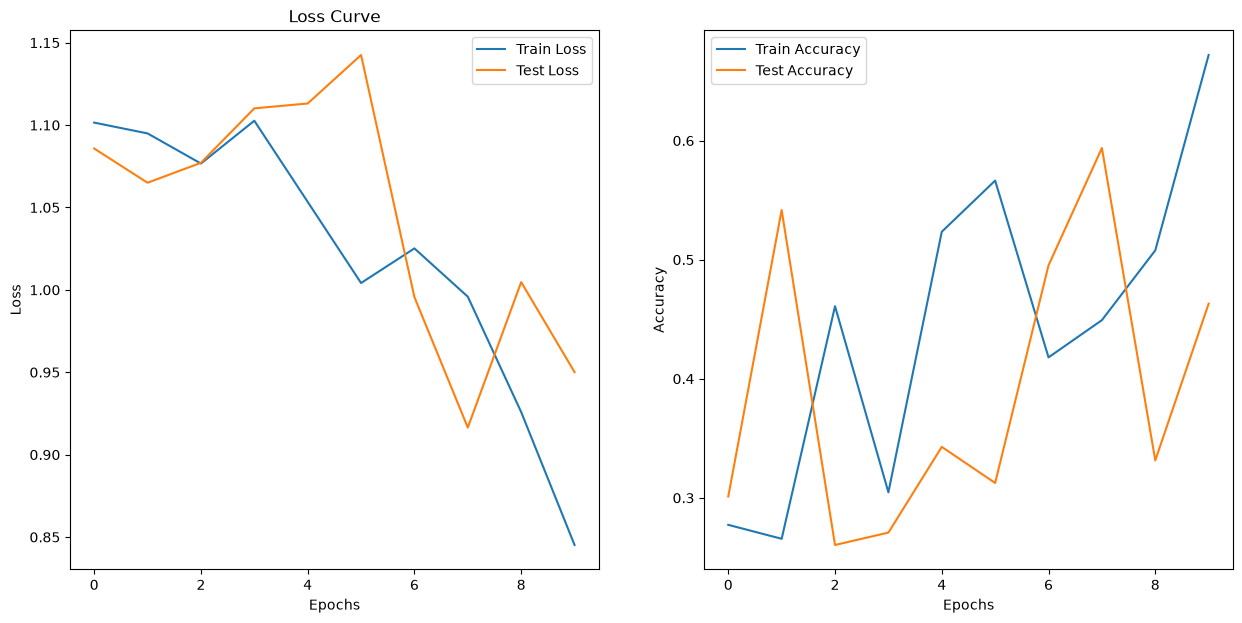

In [55]:
plot_loss_curve(results=model_0_results)

#### 8. Model 1: With Data Augmentation

##### 8.1 Create transform with data augmentation

In [56]:
# Create training transform with TrivialAugment
from torchvision import transforms
train_transform_trivial = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
    ])

##### 8.2 Create train and test `Dataset's` and `DataLoader's` with data augmentiaon 

In [57]:
# Turn image folders into datasets 
train_data_augmented = datasets.ImageFolder(root=train_dir,
                                       transform=train_transform_trivial)
test_data_simple = datatsets = datasets.ImageFolder(root=test_dir,
                                                    transform=test_transform_simple)

In [58]:
# Turn our dataset into dataloaders
BATCH_SIZE = 32

train_dataloader_augmented = DataLoader(dataset=train_data_augmented,
                                        batch_size=BATCH_SIZE,
                                        shuffle=True)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)

##### 8.3 Create Model 1

In [59]:
model_1 = TinyVGG(input_shape=3,
                  hidden_units=50,
                  output_shape=len(train_data_augmented.classes)).to(device)

NUM_EPOCHS = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.001)
model_1_results = train(model=model_1,
                        train_dataloader=train_dataloader_augmented,
                        test_dataloader=test_dataloader_simple,
                        loss_fn=loss_fn,
                        optimizer=optimizer,
                        epochs=NUM_EPOCHS,
                        device=device)

 10%|█         | 1/10 [00:00<00:06,  1.35it/s]

Epoch: 0 | Train loss: 1.1109 | Train Acuuracy: 0.29 | Test Loss: 1.0597 | Test Accuracy: 0.53


 20%|██        | 2/10 [00:01<00:05,  1.43it/s]

Epoch: 1 | Train loss: 1.0902 | Train Acuuracy: 0.29 | Test Loss: 1.0089 | Test Accuracy: 0.55


 30%|███       | 3/10 [00:02<00:04,  1.46it/s]

...

Epoch: 7 | Train loss: 0.9992 | Train Acuuracy: 0.52 | Test Loss: 1.0228 | Test Accuracy: 0.39


 90%|█████████ | 9/10 [00:06<00:00,  1.32it/s]

Epoch: 8 | Train loss: 0.9370 | Train Acuuracy: 0.60 | Test Loss: 1.0276 | Test Accuracy: 0.46


100%|██████████| 10/10 [00:07<00:00,  1.37it/s]

Epoch: 9 | Train loss: 0.9191 | Train Acuuracy: 0.57 | Test Loss: 0.9836 | Test Accuracy: 0.46


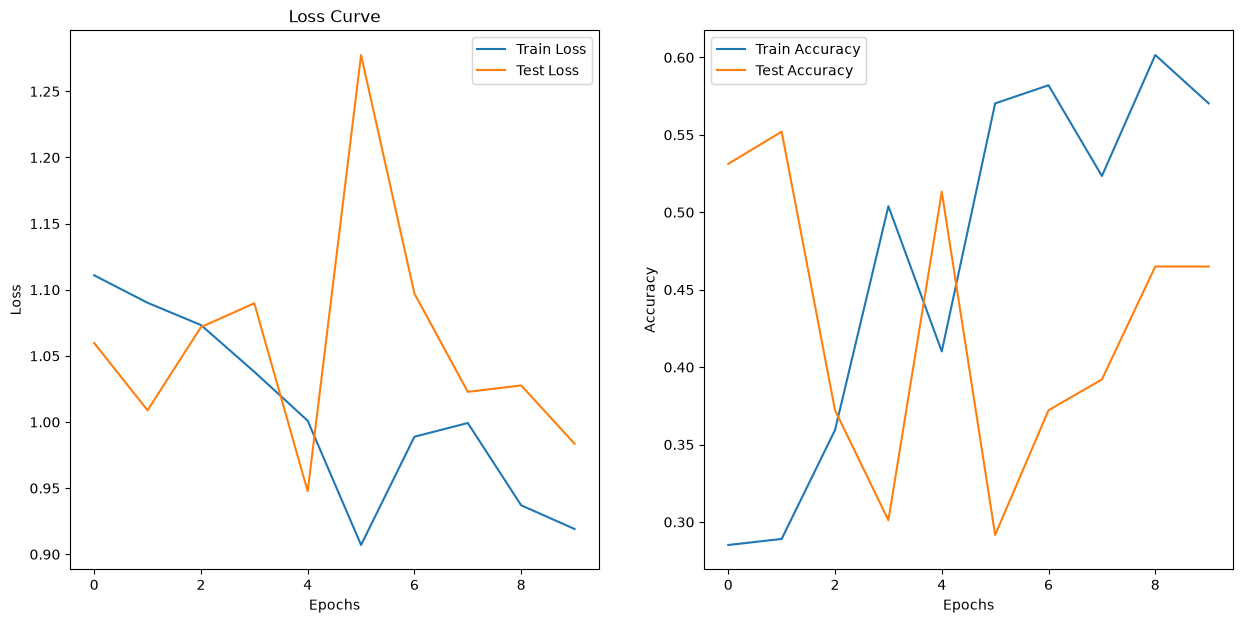

In [60]:
plot_loss_curve(results=model_1_results)


#### 9. Make a prediction on a custom image

In [61]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "pizza.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://www.recipetineats.com/tachyon/2023/05/Garlic-cheese-pizza_9.jpg?resize=900%2C1125&zoom=0.86")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

data_custom\pizza.jpeg already exists, skipping download.



##### 9.1 Loading in a custom image with PyTorch

In [62]:
import torchvision

# Read in custom image
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))

# Print out image data
print(f"Custom image tensor:\n{custom_image_uint8}\n")
print(f"Custom image shape: {custom_image_uint8.shape}\n")
print(f"Custom image dtype: {custom_image_uint8.dtype}")

Custom image tensor:
tensor([[[224, 226, 228,  ..., 211, 205, 200],
         [223, 224, 227,  ..., 211, 206, 201],
         [223, 225, 227,  ..., 211, 207, 203],
         ...,
         [208, 207, 205,  ...,  79,  81,  79],
         [207, 206, 204,  ...,  80,  85,  78],
         [204, 204, 203,  ...,  64,  71,  77]],

        [[218, 220, 222,  ..., 192, 186, 181],
         [217, 218, 221,  ..., 192, 187, 182],
         [217, 219, 221,  ..., 192, 188, 184],
         ...,
         [191, 190, 190,  ...,  52,  54,  52],
         [190, 189, 189,  ...,  53,  58,  51],
         [187, 187, 188,  ...,  37,  44,  50]],

        [[220, 222, 224,  ..., 185, 179, 174],
         [219, 220, 223,  ..., 185, 180, 175],
         [219, 221, 223,  ..., 185, 181, 177],
         ...,
         [184, 183, 185,  ...,  41,  43,  41],
         [183, 182, 184,  ...,  42,  47,  40],
         [180, 180, 183,  ...,  26,  33,  39]]], dtype=torch.uint8)

Custom image shape: torch.Size([3, 968, 774])

Custom image dtype

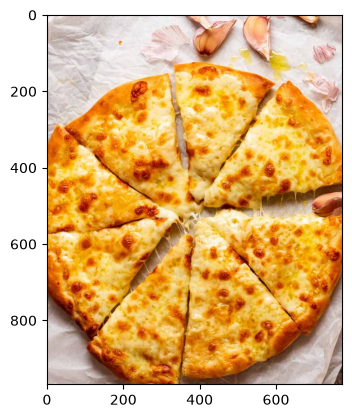

In [63]:
plt.imshow(custom_image_uint8.permute(1,2,0))

##### 9.2 Making a prediction on a custom image with a pytorch model

In [64]:
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255
custom_image

tensor([[[0.8784, 0.8863, 0.8941,  ..., 0.8275, 0.8039, 0.7843],
         [0.8745, 0.8784, 0.8902,  ..., 0.8275, 0.8078, 0.7882],
         [0.8745, 0.8824, 0.8902,  ..., 0.8275, 0.8118, 0.7961],
         ...,
         [0.8157, 0.8118, 0.8039,  ..., 0.3098, 0.3176, 0.3098],
         [0.8118, 0.8078, 0.8000,  ..., 0.3137, 0.3333, 0.3059],
         [0.8000, 0.8000, 0.7961,  ..., 0.2510, 0.2784, 0.3020]],

        [[0.8549, 0.8627, 0.8706,  ..., 0.7529, 0.7294, 0.7098],
         [0.8510, 0.8549, 0.8667,  ..., 0.7529, 0.7333, 0.7137],
         [0.8510, 0.8588, 0.8667,  ..., 0.7529, 0.7373, 0.7216],
         ...,
         [0.7490, 0.7451, 0.7451,  ..., 0.2039, 0.2118, 0.2039],
         [0.7451, 0.7412, 0.7412,  ..., 0.2078, 0.2275, 0.2000],
         [0.7333, 0.7333, 0.7373,  ..., 0.1451, 0.1725, 0.1961]],

        [[0.8627, 0.8706, 0.8784,  ..., 0.7255, 0.7020, 0.6824],
         [0.8588, 0.8627, 0.8745,  ..., 0.7255, 0.7059, 0.6863],
         [0.8588, 0.8667, 0.8745,  ..., 0.7255, 0.7098, 0.

In [65]:
# Create tramsfrom pipeline to resize image
custom_image_transform = transforms.Compose([transforms.Resize(size=(64,64))])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)

custom_image_transformed.shape

torch.Size([3, 64, 64])

In [66]:
# Adding a batch to match the shape 
custom_image_unsqueezed = custom_image_transformed.unsqueeze(0)
custom_image_unsqueezed.shape

torch.Size([1, 3, 64, 64])

In [67]:
model_1.eval()
with torch.inference_mode():
    custom_image_pred = model_1(custom_image_unsqueezed.to(device))
custom_image_pred

tensor([[ 0.0359, -0.8192, -0.5751]], device='cuda:0')

In [68]:
# convert logits to prediction probabilties
custom_image_prob = torch.softmax(custom_image_pred, dim=1)
custom_image_prob

tensor([[0.5081, 0.2161, 0.2758]], device='cuda:0')

In [69]:
# Prob to label 
custom_image_label = torch.argmax(custom_image_prob, dim=1)
custom_image_label

tensor([0], device='cuda:0')

In [70]:
class_names[custom_image_label]

'pizza'

##### 9.3 Putting custom image prediction together: building a function

In [71]:
def custom_image_prediction(model: torch.nn.Module,
                           image_path:str,
                           class_names:List[str],
                           transform=None,
                           device=device):
    # load the image 255 -> [0,1]
    custom_image = torchvision.io.read_image(str(image_path)).type(torch.float32) / 255
    # plt.imshow(custom_image.permute(1,2,0))

    if transform:
        custom_image_transformed = transform(custom_image)
    else: 
        # Create tramsfrom pipeline to resize image
        custom_image_transform = transforms.Compose([transforms.Resize(size=(64,64))])

        # Transform target image
        custom_image_transformed = custom_image_transform(custom_image)

    # Adding batch
    custom_image_unsqueezed = custom_image_transformed.unsqueeze(0)

    model.eval()
    with torch.inference_mode():
        custom_image_pred = model(custom_image_unsqueezed.to(device))
    custom_image_prob =  torch.softmax(custom_image_pred, dim=1)
    custom_image_label = torch.argmax(custom_image_prob,dim=1)

    # plot the image alongside the prediction 
    plt.imshow(custom_image_transformed.permute(1, 2, 0))
    if class_names:
        title = f"pred: {class_names[custom_image_label.cpu()]} | Prob: {custom_image_prob.max().cpu():.3f}"
    else:
        title = f"pred: {custom_image_label} | Prob: {custom_image_prob.max().cpu():.3f}"
    plt.title(title)
    plt.axis("off")

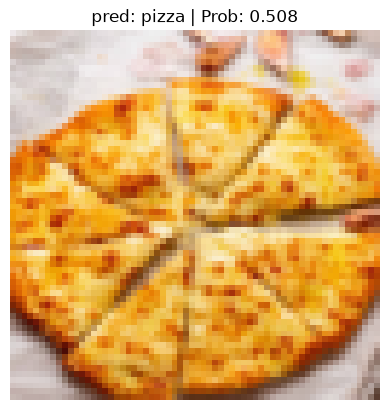

In [72]:
# Pred on custom image prediction function
custom_image_prediction(model=model_1,
                        image_path=custom_image_path,
                        class_names=class_names,
                        device=device)